In [202]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [203]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
import numpy as np
import pandas as pd
from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

In [204]:
x = np.array([16,32,64,128,256,512,1024])
print(len(x))

7


In [205]:
fl = np.array([589630667,589653330,589623068,589635963,731500653,1106031048,2133070518])
db = np.array([
3989195832
,3989176037
,5564500551
,9946500587
,19888000306
,39776009075
,79552009949
])
fl2 = np.array([
2923635240
,2923647154
,3099002040
,3106467078
,4909794376
,9360128839
,18966647761
])
db2 = np.array([
27642639445
,27642501200
,43742000683
,84272000372
,168175725404
,336247135915
,0
])
fl2p = np.array([
5795202184
,5792853210
,6082061416
,6122266168
,7395436935
,13687414030
,28109203749
])
db2p = np.array([
38323275831
,38323145527
,61791899734
,122381655401
,244747545448
,0
,0
])

fl =fl/100000.;
fl2 = fl2/100000.;
db =db/100000.;
db2 =db2/100000.;
fl2p =fl2p/100000.;
db2p =db2p/100000.;

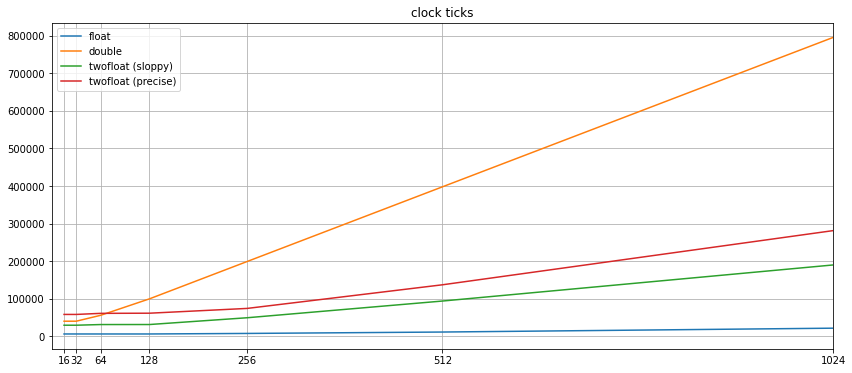

In [206]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(x,fl, label="float")
plt.plot(x,db, label="double")
plt.plot(x,fl2, label="twofloat (sloppy)")
#plt.plot(x,db2, label="twodouble (sloppy)")
plt.plot(x,fl2p, label="twofloat (precise)")
#plt.plot(x,db2p, label="twodouble (precise)")
plt.xlim(0., 1024.)
plt.xticks(x)
#plt.ylim(0.0, 50.)
#plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('clock ticks')
ax.grid(which='both')
plt.show()

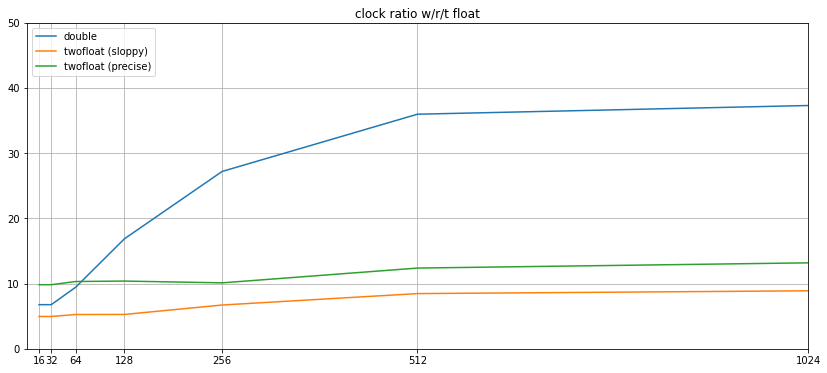

In [207]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(x,db/fl, label="double")
plt.plot(x,fl2/fl, label="twofloat (sloppy)")
#plt.plot(x,db2/fl, label="twodouble (sloppy)")
plt.plot(x,fl2p/fl, label="twofloat (precise)")
#plt.plot(x,db2p/fl, label="twodouble (precise)")
plt.xlim(0., 1024.)
plt.ylim(0.0, 50.)
plt.xticks(x)
#plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('clock ratio w/r/t float')
ax.grid(which='both')
plt.show()

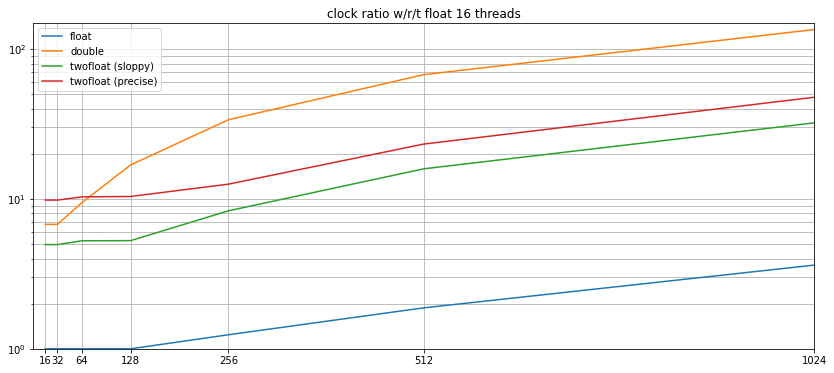

In [208]:
fig, ax = plt.subplots(figsize=(14, 6))
f0 = fl[0]
plt.plot(x,fl/f0, label="float")
plt.plot(x,db/f0, label="double")
plt.plot(x,fl2/f0, label="twofloat (sloppy)")
#plt.plot(x,db2/f0, label="twodouble (sloppy)")
plt.plot(x,fl2p/f0, label="twofloat (precise)")
#plt.plot(x,db2p/f0, label="twodouble (precise)")
plt.xlim(0., 1024.)
plt.ylim(1., 150.)
plt.xticks(x)
plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('clock ratio w/r/t float 16 threads')
ax.grid(which='both')
plt.show()

In [209]:
y = np.array([16,32,64,128,256])
print(len(x))

ff_f = np.array([
1288368,
497820,
252707,
126073,
68425
])
ff_d = np.array([
5411519,
2621873,
1524491,
1059593,
1029502
    ])
ff_ff = np.array([
2187204,
991538,
506408,
284532,
188452
    ])
ff_dd = np.array([
14874981,
7472511,
5206356,
4674303,
4675654
])
ff_fp = np.array([
2628152,
1403309,
669913,
302752,
239157
])
ff_dp = np.array([
19645488,
9847850,
7404072,
6837555,
6832437
])


bl_f = np.array([
27521824,
13407443,
6561255,
4176432,
2623227
])
bl_d = np.array([
108437488,
54277375,
31731854,
24297314,
24042964
])
bl_ff = np.array([
69262194,
34165171,
17985020,
10614413,
6460824
])
bl_dd = np.array([
359179560,
180164547,
126780782,
116595389,
116399873
])
bl_fp = np.array([
95486141,
50528670,
24005601,
13655488,
8120195
])
bl_dp = np.array([
487228214,
244291783,
181131207,
170289246,
170038042
])

7


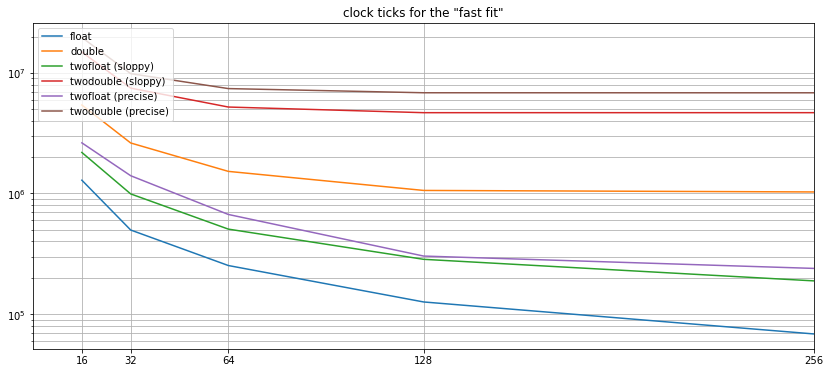

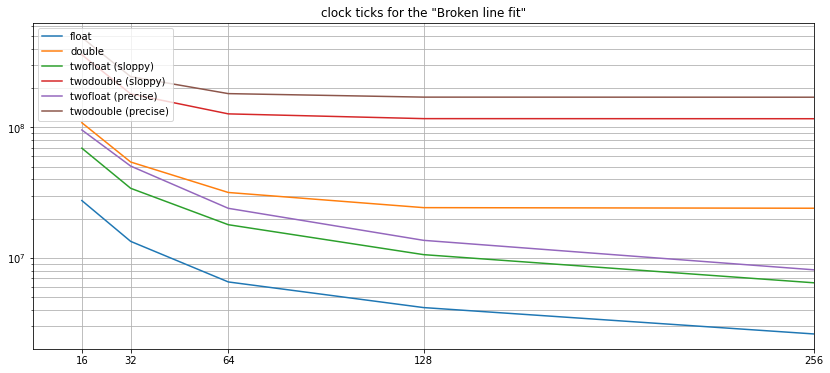

In [210]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(y,ff_f, label="float")
plt.plot(y,ff_d, label="double")
plt.plot(y,ff_ff, label="twofloat (sloppy)")
plt.plot(y,ff_dd, label="twodouble (sloppy)")
plt.plot(y,ff_fp, label="twofloat (precise)")
plt.plot(y,ff_dp, label="twodouble (precise)")
plt.xlim(0., 256.)
plt.xticks(y)
#plt.ylim(0.0, 50.)
plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('clock ticks for the "fast fit"')
ax.grid(which='both')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(y,bl_f, label="float")
plt.plot(y,bl_d, label="double")
plt.plot(y,bl_ff, label="twofloat (sloppy)")
plt.plot(y,bl_dd, label="twodouble (sloppy)")
plt.plot(y,bl_fp, label="twofloat (precise)")
plt.plot(y,bl_dp, label="twodouble (precise)")
plt.xlim(0., 256.)
plt.xticks(y)
#plt.ylim(0.0, 50.)
plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('clock ticks for the "Broken line fit"')
ax.grid(which='both')
plt.show()

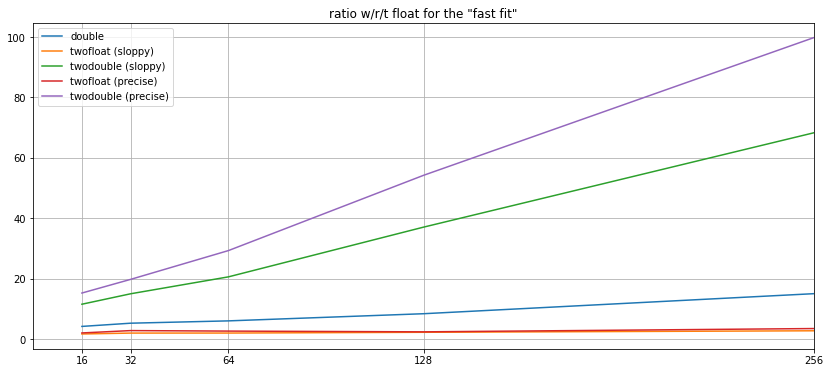

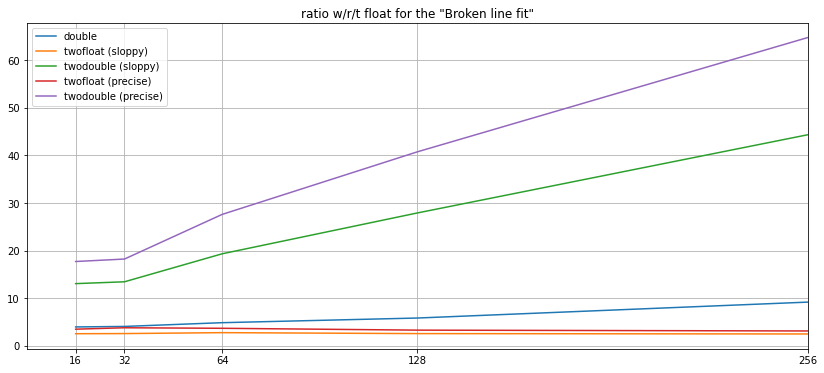

In [211]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(y,ff_d/ff_f, label="double")
plt.plot(y,ff_ff/ff_f, label="twofloat (sloppy)")
plt.plot(y,ff_dd/ff_f, label="twodouble (sloppy)")
plt.plot(y,ff_fp/ff_f, label="twofloat (precise)")
plt.plot(y,ff_dp/ff_f, label="twodouble (precise)")
plt.xlim(0., 256.)
plt.xticks(y)
#plt.ylim(0.0, 50.)
#plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('ratio w/r/t float for the "fast fit"')
ax.grid(which='both')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(y,bl_d/bl_f, label="double")
plt.plot(y,bl_ff/bl_f, label="twofloat (sloppy)")
plt.plot(y,bl_dd/bl_f, label="twodouble (sloppy)")
plt.plot(y,bl_fp/bl_f, label="twofloat (precise)")
plt.plot(y,bl_dp/bl_f, label="twodouble (precise)")
plt.xlim(0., 256.)
plt.xticks(y)
#plt.ylim(0.0, 50.)
#plt.yscale("log")
plt.legend(loc='upper left')
ax.set_title('ratio w/r/t float for the "Broken line fit"')
ax.grid(which='both')
plt.show()